# Caderno 0 - Baixar docs.csv

As avaliações humanas, o qrel e o arquivo de queries já foi tratado em outro notebook privado e estão disponíveis na pasta 'dados\inputs\0 - qrel - docs - query - raw_human_eval\'.

No entanto, por conta do tamanho do arquivo docs.csv, não coloquei ele na pasta.

O intuito desse caderno é baixar a base de documentos e gerar o docs.csv.

Obs.: Os dados do qrels, docs e query se referem apenas a documentos públicos e as avaliações individuais estão anonimizadas.nonimizadas.

# 1. Parâmetros para configurar

In [1]:
URL_DOCS = "https://sites.tcu.gov.br/dados-abertos/normas/arquivos/norma.csv"
ARQUIVO_DOCS = './dados/outputs/0 - qrel - docs - query - raw_human_eval/docs.csv'

# 2. Geração do arquivo docs.csv

In [2]:
from pathlib import Path
import sys
import requests
import pandas as pd
from datetime import datetime

Função para fazer download da base de dados no site do TCU

In [3]:
DEST_DOCS = Path(ARQUIVO_DOCS)

In [4]:
def gerar_arquivo_docs():
    # 1) Se o arquivo já existe, sai sem fazer nada
    if DEST_DOCS.exists():
        print(f"{DEST_DOCS} já existe. Nada a fazer.")
        return
    
    # 2) Baixa o arquivo e salva em ./dados/qrels/docs.csv
    DEST_DOCS.parent.mkdir(parents=True, exist_ok=True)
    try:
        print(f"Baixando {URL_DOCS} ...")
        with requests.get(URL_DOCS, stream=True, timeout=120) as r:
            r.raise_for_status()
            with open(DEST_DOCS, "wb") as f:
                for chunk in r.iter_content(chunk_size=1 << 20):
                    if chunk:
                        f.write(chunk)
        print(f"Arquivo salvo em {DEST_DOCS}")
    except Exception as e:
        print(f"Falha no download: {e}", file=sys.stderr)

Função para filtrar apenas os dados antes de 1/7/2024

In [5]:
def tratar_e_filtrar_docs():
    # 3) Abre o arquivo como DataFrame usando '|' como separador
    try:
        df = pd.read_csv(DEST_DOCS, dtype=str, na_filter=False)
    except Exception as e:
        print(f"Erro ao ler o CSV: {e}", file=sys.stderr)
    
    # 4) Verifica se há registros com DATAINICIOVIGENCIA vazio.
    # Essa etapa é apenas uma verificação dos dados.
    col = "DATAINICIOVIGENCIA"
    
    vazios = df[col].str.strip().eq("")
    n_vazios = int(vazios.sum())
    
    if n_vazios > 0:
        print(f"Há {n_vazios} registros com '{col}' vazio.")
    else:
        print(f"Não há registros com '{col}' vazio.")

    # 5) Corrige manualmente datas com anos errados (detectados previamente numa análise manual)
    df[col] = df[col].replace({
        "04/04/0208": "04/04/2018",
        "23/08/0210": "23/08/2010"
    })

    # Substitui strings vazias por NA
    df[col] = df[col].replace("", pd.NA)

    # Converte para datetime, removendo inválidas
    df['DATA_FORMATO_DATETIME'] = pd.to_datetime(df[col], format="%d/%m/%Y", errors="coerce")
    df = df.dropna(subset=['DATA_FORMATO_DATETIME'])

    # Filtra datas anteriores a 1º de julho de 2024
    limite = datetime(2024, 7, 1)
    df_filtrado = df[df['DATA_FORMATO_DATETIME'] < limite]

    # Filtra apenas os campos desejados:
    campos_desejados = ['KEY', 'UNIDADEBASICAAUTORA', 'ORIGEM', 'NUMNORMA', 'ANONORMA', 'TIPONORMA', 'TITULO', 'ASSUNTO',
                        'TEXTONORMA', 'DATAINICIOVIGENCIA', 'DATAFIMVIGENCIA', 'SITUACAO', 'TEXTOANEXO', 'TEMA', 'TAGSVCE', 'NORMARELACIONADA']
    df_filtrado = df_filtrado[campos_desejados]

    print(f"Restaram {len(df_filtrado)} registros com DATAINICIOVIGENCIA anterior a 01/07/2024.")

    df_filtrado.to_csv(DEST_DOCS, index=False)

    return df_filtrado

In [6]:
gerar_arquivo_docs()
df = tratar_e_filtrar_docs()

# Observação: tem que ter 14469 registros

dados\outputs\0 - qrel - docs - query - raw_human_eval\docs.csv já existe. Nada a fazer.
Não há registros com 'DATAINICIOVIGENCIA' vazio.
Restaram 14469 registros com DATAINICIOVIGENCIA anterior a 01/07/2024.


# 3. Algumas estatísticas da base de documentos

Total de vazios (NA):

In [7]:
total_linhas = len(df)

vazios_por_coluna = df.isna().sum() + df.apply(
    lambda col: col.astype(str).str.strip().eq("").sum()
)

resumo = pd.DataFrame({
    "Total Vazios": vazios_por_coluna,
    "% Vazios": (vazios_por_coluna / total_linhas * 100).round(2)
}).sort_values("Total Vazios", ascending=False)

resumo

,Total Vazios,% Vazios
DATAFIMVIGENCIA,13629,94.19
TEXTOANEXO,13237,91.49
NORMARELACIONADA,9918,68.55
ASSUNTO,7191,49.70
TAGSVCE,3849,26.60
TEMA,3686,25.48
TEXTONORMA,5,0.03
KEY,0,0.00
UNIDADEBASICAAUTORA,0,0.00
ORIGEM,0,0.00


CDF do tamanho do texto:

In [8]:
from formatador import html_to_plain_text

# 1️⃣ Criar coluna TEXTO_SEM_HTML
df['TEXTO_SEM_HTML'] = df['TEXTONORMA'].fillna("").apply(html_to_plain_text)

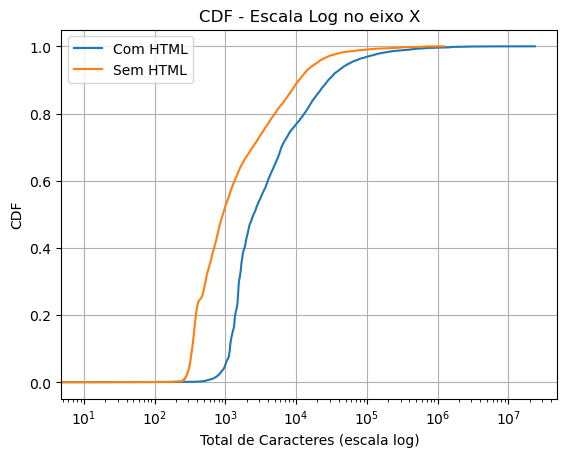

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 2️⃣ Calcular total de caracteres
tamanho_html = df['TEXTONORMA'].fillna("").astype(str).str.len()
tamanho_sem_html = df['TEXTO_SEM_HTML'].fillna("").astype(str).str.len()

# 3️⃣ Ordenar valores
html_ord = np.sort(tamanho_html)
sem_html_ord = np.sort(tamanho_sem_html)

# 4️⃣ Calcular CDF
cdf_html = np.arange(1, len(html_ord) + 1) / len(html_ord)
cdf_sem_html = np.arange(1, len(sem_html_ord) + 1) / len(sem_html_ord)

plt.figure()
plt.plot(html_ord, cdf_html, label="Com HTML")
plt.plot(sem_html_ord, cdf_sem_html, label="Sem HTML")

plt.xscale("log")  # 🔥 chave aqui
plt.xlabel("Total de Caracteres (escala log)")
plt.ylabel("CDF")
plt.title("CDF - Escala Log no eixo X")
plt.legend()
plt.grid(True)
plt.show()

In [13]:
percentis = [5, 25, 50, 75, 90, 95, 99]

tabela_percentis = pd.DataFrame({
    "Percentil": percentis,
    "Com_HTML": [np.percentile(tamanho_html, p) for p in percentis],
    "Sem_HTML": [np.percentile(tamanho_sem_html, p) for p in percentis]
})

tabela_percentis

,Percentil,Com_HTML,Sem_HTML
0,5,991.4,312.00
1,25,1500.0,451.00
2,50,2504.0,923.00
3,75,8525.0,3475.00
4,90,28787.0,11067.80
5,95,57916.6,19508.20
6,99,391809.2,95383.56
